# Convex Optimization — Image Restoration via TV Regularization

**Project:** Non-blind image deblurring with synthetic degradation  
**Model:**

$$\min_{\mathbf{u}} \frac{1}{2} \| K\mathbf{u} - \mathbf{f} \|_2^2 + \lambda \|\nabla \mathbf{u}\|_1 \quad \text{s.t.} \quad 0 \leq \mathbf{u} \leq 1$$

where:
- $\mathbf{u} \in \mathbb{R}^{N^2}$ — the restored image (flattened)
- $K \in \mathbb{R}^{N^2 \times N^2}$ — the **known** sparse, row-normalized Gaussian blur operator
- $\mathbf{f} \in \mathbb{R}^{N^2}$ — the observed degraded image (blurred + salt-and-pepper noise)
- $\lambda > 0$ — regularization weight controlling the fidelity-smoothness tradeoff
- $\|\nabla \mathbf{u}\|_1$ — **isotropic** Total Variation (TV), rotation-invariant, promotes piecewise-smooth solutions

**Test image:** Cameraman (128x128, grayscale, normalized to $[0,1]$)  
**Degradations:** Heavy Gaussian blur ($\sigma=3$) + Salt-and-Pepper noise ($p=0.05$)

## 0. Imports & Setup

In [1]:
%pip install -qq numpy matplotlib cvxpy scipy scikit-image

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import time

from scipy.ndimage import gaussian_filter, median_filter
from scipy.sparse import lil_matrix, csr_matrix, diags
from skimage.data import camera
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

np.random.seed(42)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"CVXPY version : {cp.__version__}")
print(f"Output dir    : {os.path.abspath(OUTPUT_DIR)}")

CVXPY version : 1.8.2
Output dir    : /Users/reynaldi/Documents/convex_441/ipynb/outputs


## 1. Ground Truth Image

Image shape : (128, 128)
Pixel range : [0.0000, 1.0000]


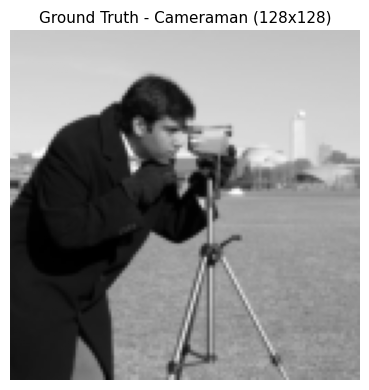

In [3]:
N = 128

def load_ground_truth(size):
    img = camera()
    img = resize(img, (size, size), anti_aliasing=True).astype(np.float64)
    return (img - img.min()) / (img.max() - img.min())

u_true = load_ground_truth(N)
print(f"Image shape : {u_true.shape}")
print(f"Pixel range : [{u_true.min():.4f}, {u_true.max():.4f}]")

plt.figure(figsize=(4, 4))
plt.imshow(u_true, cmap='gray', vmin=0, vmax=1)
plt.title('Ground Truth - Cameraman (128x128)', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/00_ground_truth.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Synthetic Degradation Pipeline

1. **Gaussian blur** ($\sigma = 3$) — simulates out-of-focus acquisition  
2. **Salt-and-pepper noise** ($p = 0.05$) — simulates sensor imperfections

The blur kernel $K$ is **known**, making this non-blind deconvolution and keeping everything convex.

PSNR (degraded vs. truth) : 16.60 dB
SSIM (degraded vs. truth) : 0.2290


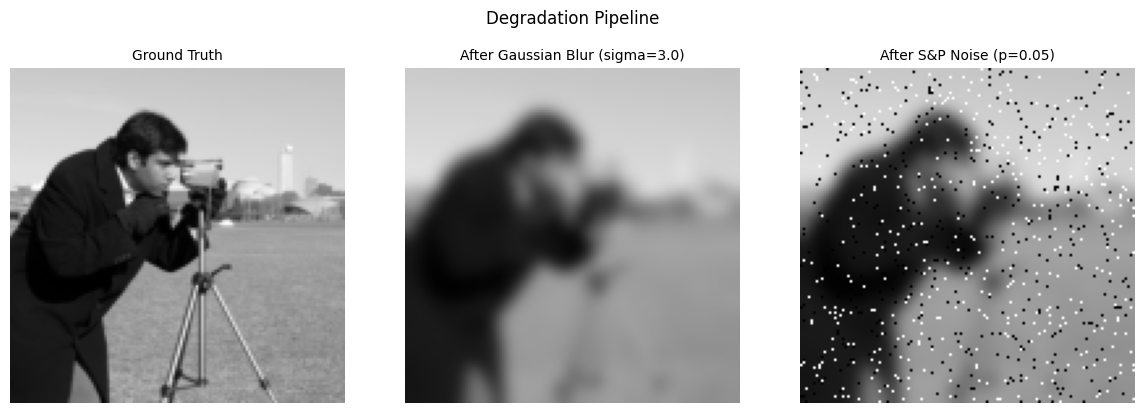

In [4]:
BLUR_SIGMA  = 3.0
KERNEL_SIZE = 11
NOISE_PROB  = 0.05

def make_blur_kernel(sigma, size):
    k = np.zeros((size, size))
    k[size // 2, size // 2] = 1.0
    k = gaussian_filter(k, sigma=sigma)
    return k / k.sum()

def apply_blur(img, sigma):
    return gaussian_filter(img, sigma=sigma)

def add_salt_pepper(img, prob):
    noisy = img.copy()
    mask  = np.random.rand(*img.shape)
    noisy[mask < prob / 2]     = 0.0
    noisy[mask > 1 - prob / 2] = 1.0
    return noisy

kernel    = make_blur_kernel(BLUR_SIGMA, KERNEL_SIZE)
u_blurred = apply_blur(u_true, BLUR_SIGMA)
f_obs     = np.clip(add_salt_pepper(u_blurred, NOISE_PROB), 0.0, 1.0)

print(f"PSNR (degraded vs. truth) : {psnr(u_true, f_obs, data_range=1.0):.2f} dB")
print(f"SSIM (degraded vs. truth) : {ssim(u_true, f_obs, data_range=1.0):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(axes,
    [u_true, u_blurred, f_obs],
    ['Ground Truth', f'After Gaussian Blur (sigma={BLUR_SIGMA})', f'After S&P Noise (p={NOISE_PROB})']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Degradation Pipeline', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_degradation_pipeline.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Build the Sparse, Row-Normalized Blur Operator $K$

**Why row normalization?** Boundary pixels only overlap with part of the kernel (zero-padding truncates the support). Without normalization, boundary rows of $K$ sum to less than 1 — the forward model becomes inconsistent at edges, distorting the deconvolution signal. Row-normalizing:

$$K_{\text{norm}} = D^{-1} K, \quad D_{ii} = \sum_j K_{ij}$$

ensures every pixel sees a proper probability-weighted average regardless of its position — a necessary condition for a well-posed deconvolution problem.

In [5]:
def build_blur_matrix(N, kernel):
    """
    Build the sparse, row-normalized N2xN2 convolution matrix.
    Row normalization corrects for boundary truncation so every
    row sums to exactly 1.
    """
    ks  = kernel.shape[0]
    pad = ks // 2
    n2  = N * N
    K   = lil_matrix((n2, n2), dtype=np.float64)

    for i in range(N):
        for j in range(N):
            row = i * N + j
            for ki in range(ks):
                for kj in range(ks):
                    si = i + ki - pad
                    sj = j + kj - pad
                    if 0 <= si < N and 0 <= sj < N:
                        K[row, si * N + sj] += kernel[ki, kj]

    K        = csr_matrix(K)
    row_sums = np.array(K.sum(axis=1)).flatten()
    return diags(1.0 / row_sums) @ K


print("Building sparse blur matrix K ...")
t0 = time.time()
K_sparse = build_blur_matrix(N, kernel)
print(f"Done in {time.time() - t0:.1f}s")
print(f"K shape  : {K_sparse.shape}")
print(f"Nonzeros : {K_sparse.nnz:,}")
print(f"Row sums : min={K_sparse.sum(axis=1).min():.6f}  max={K_sparse.sum(axis=1).max():.6f}  (should be 1.0)")

Ku_check = (K_sparse @ u_true.ravel()).reshape(N, N)
print(f"Max pixel error (K*u vs. gaussian_filter): {np.abs(Ku_check - u_blurred).max():.2e}")

Building sparse blur matrix K ...
Done in 3.0s
K shape  : (16384, 16384)
Nonzeros : 1,898,884
Row sums : min=1.000000  max=1.000000  (should be 1.0)
Max pixel error (K*u vs. gaussian_filter): 3.14e-02


## 4. TV Regularization Model (CVXPY)

**Isotropic TV** at pixel $(i,j)$:
$$\|\nabla u\|_{\text{iso}} = \sum_{i,j} \sqrt{(u_{i+1,j}-u_{i,j})^2 + (u_{i,j+1}-u_{i,j})^2}$$

This is **rotation-invariant** — a diagonal edge costs the same as a horizontal one of equal magnitude, avoiding the axis-aligned bias of anisotropic TV. `cp.tv(u_2d)` implements exactly this for 2D inputs.

In [6]:
LAMBDA = 0.05

def solve_tv_model(K, f_obs, lam, N, verbose=False):
    """
    Solve: min_{u in [0,1]} (1/2)||Ku - f||_2^2 + lam * TV(u)
    Returns (restored image NxN, data fidelity value, TV value).
    """
    f_flat    = f_obs.ravel()
    u         = cp.Variable(N * N, name='u')
    u_2d      = cp.reshape(u, (N, N), order='C')
    data_term = 0.5 * cp.sum_squares(K @ u - f_flat)
    tv_term   = cp.tv(u_2d)  # isotropic TV
    prob      = cp.Problem(cp.Minimize(data_term + lam * tv_term), [u >= 0, u <= 1])

    print(f"Problem is DCP : {prob.is_dcp()}")
    print(f"Variables      : {u.size:,}")
    print(f"Lambda         : {lam}")

    t0 = time.time()
    prob.solve(solver=cp.SCS, verbose=verbose, eps=1e-4, max_iters=5000)
    elapsed = time.time() - t0

    print(f"Solver status  : {prob.status}")
    print(f"Optimal value  : {prob.value:.6f}")
    print(f"Solve time     : {elapsed:.1f}s")

    u_opt = np.clip(u.value.reshape(N, N), 0.0, 1.0)
    return u_opt, float(data_term.value), float(tv_term.value)


u_tv, data_opt, tv_opt = solve_tv_model(K_sparse, f_obs, lam=LAMBDA, N=N)

Problem is DCP : True
Variables      : 16,384
Lambda         : 0.05
Solver status  : optimal
Optimal value  : 134.278714
Solve time     : 40.5s


## 5. Naive Baselines

In [7]:
u_gauss  = np.clip(gaussian_filter(f_obs, sigma=1.5), 0.0, 1.0)
u_median = np.clip(median_filter(f_obs, size=3), 0.0, 1.0)
print("Baselines computed.")

Baselines computed.


## 6. Quantitative Evaluation

In [8]:
def evaluate(name, img, ref):
    p = psnr(ref, img, data_range=1.0)
    s = ssim(ref, img, data_range=1.0)
    print(f"  {name:<25}  PSNR = {p:6.2f} dB   SSIM = {s:.4f}")
    return {'name': name, 'psnr': p, 'ssim': s}

print("=" * 60)
print("Metric comparison vs. ground truth")
print("=" * 60)
results = [
    evaluate("Degraded (f_obs)", f_obs,    u_true),
    evaluate("Gaussian filter",  u_gauss,  u_true),
    evaluate("Median filter",    u_median, u_true),
    evaluate("TV model (ours)",  u_tv,     u_true),
]
print("=" * 60)

Metric comparison vs. ground truth
  Degraded (f_obs)           PSNR =  16.60 dB   SSIM = 0.2290
  Gaussian filter            PSNR =  21.06 dB   SSIM = 0.5278
  Median filter              PSNR =  22.04 dB   SSIM = 0.6674
  TV model (ours)            PSNR =  22.53 dB   SSIM = 0.6590


## 7. Visual Comparison

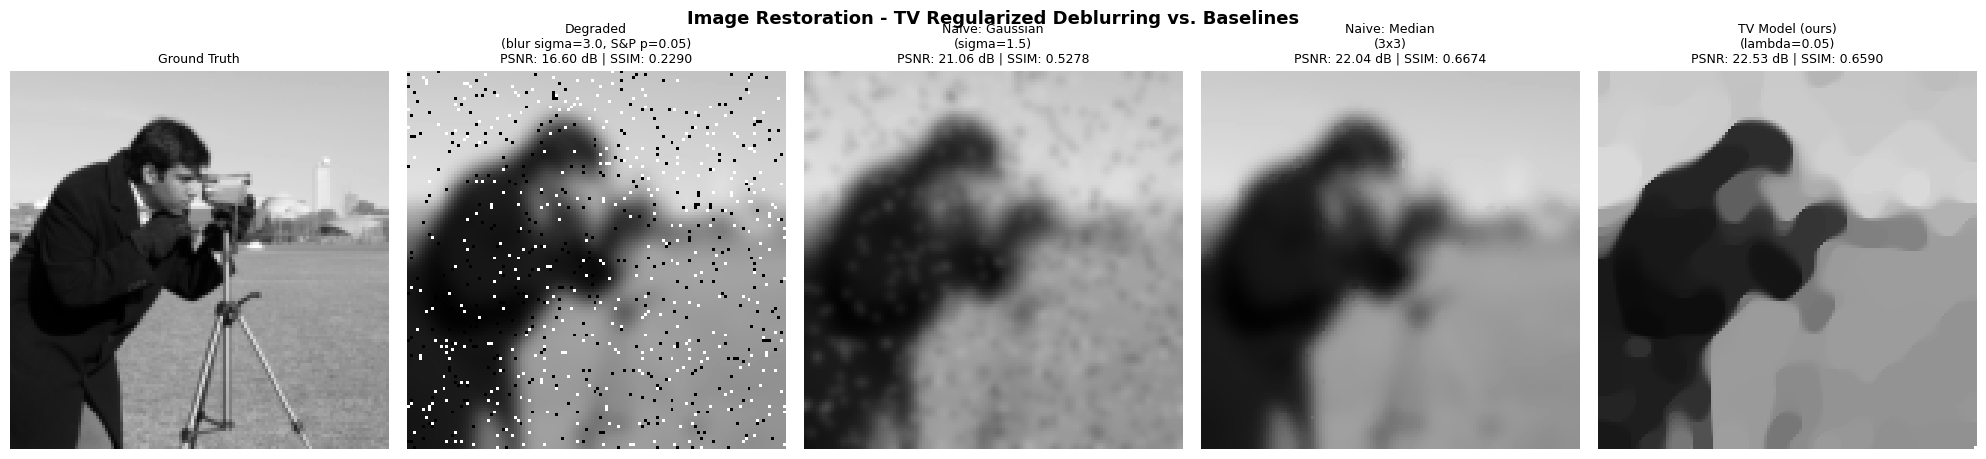

In [9]:
images   = [u_true, f_obs, u_gauss, u_median, u_tv]
titles   = [
    "Ground Truth",
    f"Degraded\n(blur sigma={BLUR_SIGMA}, S&P p={NOISE_PROB})",
    "Naive: Gaussian\n(sigma=1.5)",
    "Naive: Median\n(3x3)",
    f"TV Model (ours)\n(lambda={LAMBDA})",
]
best_idx = 1 + max(range(len(results)), key=lambda i: results[i]['psnr'])

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4.5))
for idx, (ax, img, title) in enumerate(zip(axes, images, titles)):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    label = title
    if idx > 0:
        r = results[idx - 1]
        label += f"\nPSNR: {r['psnr']:.2f} dB | SSIM: {r['ssim']:.4f}"
    ax.set_title(label, fontsize=9, pad=6)
    ax.axis('off')
    if idx == best_idx:
        for spine in ax.spines.values():
            spine.set_edgecolor('#2ecc71')
            spine.set_linewidth(3)
            spine.set_visible(True)

plt.suptitle('Image Restoration - TV Regularized Deblurring vs. Baselines',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Error Maps

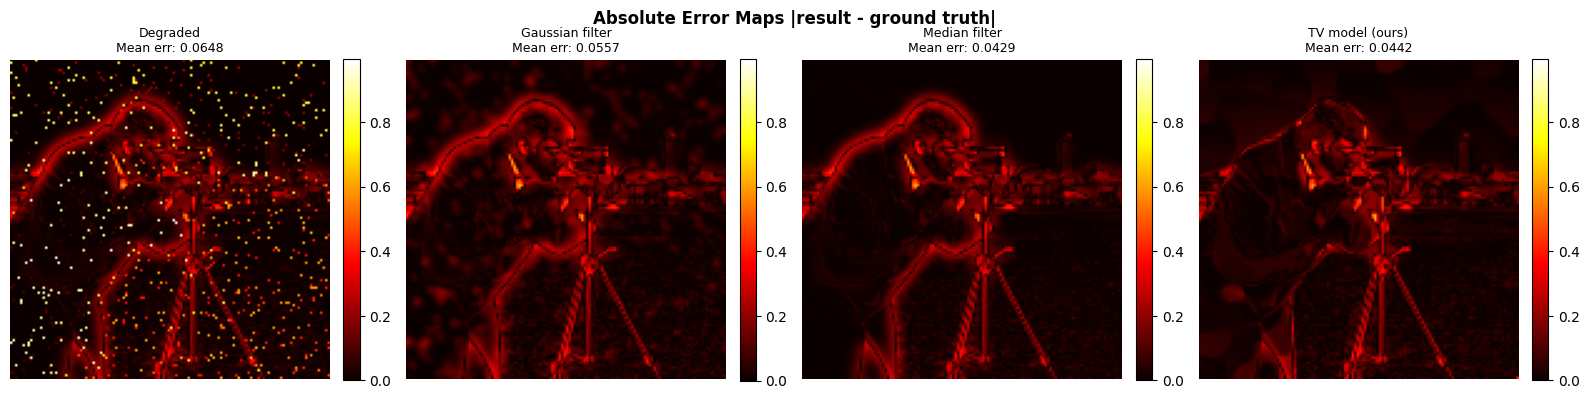

In [10]:
err_images = [f_obs, u_gauss, u_median, u_tv]
err_names  = ["Degraded", "Gaussian filter", "Median filter", "TV model (ours)"]

fig, axes = plt.subplots(1, len(err_images), figsize=(4 * len(err_images), 4))
vmax = max(np.abs(img - u_true).max() for img in err_images)

for ax, img, name in zip(axes, err_images, err_names):
    err = np.abs(img - u_true)
    im  = ax.imshow(err, cmap='hot', vmin=0, vmax=vmax)
    ax.set_title(f"{name}\nMean err: {err.mean():.4f}", fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Absolute Error Maps |result - ground truth|', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_error_maps.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Pareto Frontier: Data Fidelity vs. Total Variation

Every choice of $\lambda$ traces a point on the **Pareto frontier** — the set of Pareto-optimal solutions where no objective can improve without the other worsening:

$$\mathcal{P} = \left\{ \left(\tfrac{1}{2}\|Ku-f\|_2^2,\; \|\nabla u\|_1\right) : u^* \text{ solves the problem for some } \lambda \right\}$$

Each $\lambda$ selects a supporting hyperplane of this convex set — the optimum lies at the tangent point. The frontier is monotone decreasing: lower fidelity cost (more faithful to noisy $f$) means higher TV (less smooth), and vice versa. PSNR is color-coded to reveal where quality peaks along the curve.

> Runs at 64x64 for speed — same degradation and kernel.

In [11]:
N_small     = 64
u_true_s    = load_ground_truth(N_small)
kernel_s    = make_blur_kernel(BLUR_SIGMA, KERNEL_SIZE)
u_blurred_s = apply_blur(u_true_s, BLUR_SIGMA)
f_obs_s     = np.clip(add_salt_pepper(u_blurred_s, NOISE_PROB), 0.0, 1.0)

print("Building 64x64 blur matrix ...")
K_small = build_blur_matrix(N_small, kernel_s)
print("Done.")

lambdas     = [0.005, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5]
pareto_data = []  # (fidelity, tv, psnr, ssim, lambda)

for lam in lambdas:
    f_flat    = f_obs_s.ravel()
    u_var     = cp.Variable(N_small * N_small)
    u_2d      = cp.reshape(u_var, (N_small, N_small), order='C')
    data_term = 0.5 * cp.sum_squares(K_small @ u_var - f_flat)
    tv_term   = cp.tv(u_2d)
    prob      = cp.Problem(cp.Minimize(data_term + lam * tv_term), [u_var >= 0, u_var <= 1])
    prob.solve(solver=cp.SCS, verbose=False, eps=1e-4, max_iters=5000)

    u_opt = np.clip(u_var.value.reshape(N_small, N_small), 0.0, 1.0)
    fid   = float(data_term.value)
    tv    = float(tv_term.value)
    p     = psnr(u_true_s, u_opt, data_range=1.0)
    s     = ssim(u_true_s, u_opt, data_range=1.0)
    pareto_data.append((fid, tv, p, s, lam))
    print(f"  lambda={lam:.3f}  fidelity={fid:.2f}  TV={tv:.2f}  PSNR={p:.2f}  SSIM={s:.4f}")

Building 64x64 blur matrix ...
Done.
  lambda=0.005  fidelity=29.08  TV=160.39  PSNR=19.39  SSIM=0.4565
  lambda=0.010  fidelity=29.36  TV=120.50  PSNR=20.82  SSIM=0.5552
  lambda=0.020  fidelity=29.67  TV=98.34  PSNR=21.28  SSIM=0.6216
  lambda=0.050  fidelity=30.19  TV=81.96  PSNR=21.03  SSIM=0.6266
  lambda=0.080  fidelity=30.67  TV=74.43  PSNR=20.66  SSIM=0.6113
  lambda=0.100  fidelity=30.96  TV=71.22  PSNR=20.43  SSIM=0.6025
  lambda=0.150  fidelity=31.50  TV=66.80  PSNR=20.04  SSIM=0.5856
  lambda=0.200  fidelity=31.95  TV=64.21  PSNR=19.79  SSIM=0.5790
  lambda=0.300  fidelity=32.92  TV=60.27  PSNR=19.32  SSIM=0.5675
  lambda=0.500  fidelity=35.21  TV=54.48  PSNR=18.51  SSIM=0.5448


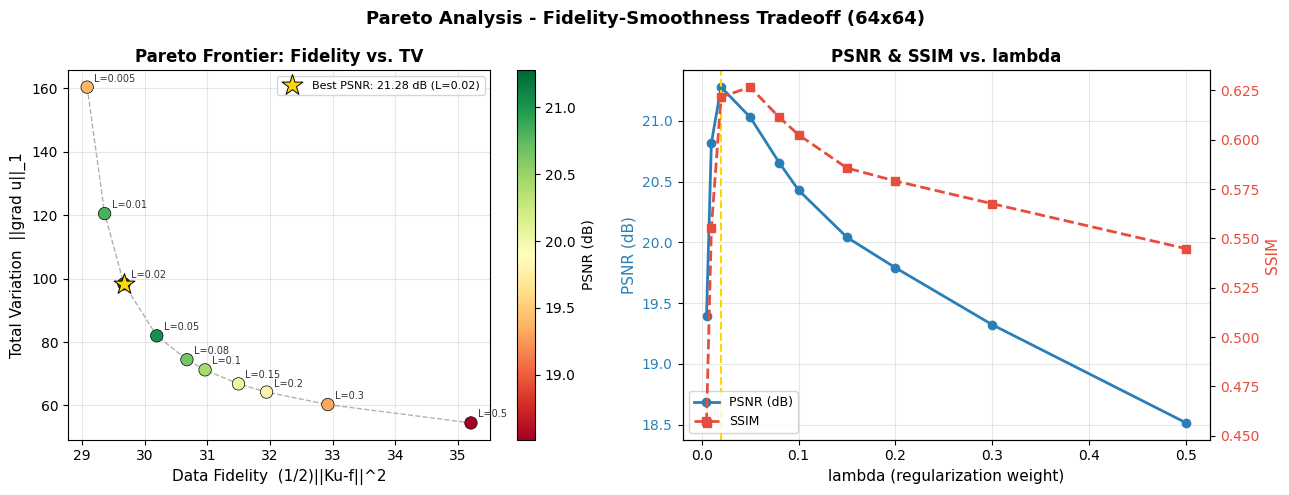

In [12]:
fids  = [d[0] for d in pareto_data]
tvs   = [d[1] for d in pareto_data]
psnrs = [d[2] for d in pareto_data]
ssims = [d[3] for d in pareto_data]
lams  = [d[4] for d in pareto_data]
best_p_idx = int(np.argmax(psnrs))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Pareto frontier colored by PSNR
ax = axes[0]
sc = ax.scatter(fids, tvs, c=psnrs, cmap='RdYlGn', s=80, zorder=3,
                edgecolors='k', linewidths=0.5)
ax.plot(fids, tvs, '--', color='gray', linewidth=1, zorder=2, alpha=0.6)
for fid, tv, lam in zip(fids, tvs, lams):
    ax.annotate(f"L={lam}", (fid, tv), textcoords='offset points',
                xytext=(5, 4), fontsize=7, color='#333333')
ax.scatter([fids[best_p_idx]], [tvs[best_p_idx]], marker='*', s=250,
           color='gold', edgecolors='k', linewidths=0.7, zorder=4,
           label=f"Best PSNR: {psnrs[best_p_idx]:.2f} dB (L={lams[best_p_idx]})")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('PSNR (dB)', fontsize=10)
ax.set_xlabel('Data Fidelity  (1/2)||Ku-f||^2', fontsize=11)
ax.set_ylabel('Total Variation  ||grad u||_1', fontsize=11)
ax.set_title('Pareto Frontier: Fidelity vs. TV', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: PSNR and SSIM vs lambda
ax2 = axes[1]
l1, = ax2.plot(lams, psnrs, 'o-', color='#2980b9', linewidth=2, markersize=6, label='PSNR (dB)')
ax2.set_xlabel('lambda (regularization weight)', fontsize=11)
ax2.set_ylabel('PSNR (dB)', color='#2980b9', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#2980b9')
ax2.axvline(lams[best_p_idx], color='gold', linestyle='--', linewidth=1.5)
ax3 = ax2.twinx()
l2, = ax3.plot(lams, ssims, 's--', color='#e74c3c', linewidth=2, markersize=6, label='SSIM')
ax3.set_ylabel('SSIM', color='#e74c3c', fontsize=11)
ax3.tick_params(axis='y', labelcolor='#e74c3c')
ax2.legend([l1, l2], ['PSNR (dB)', 'SSIM'], fontsize=9, loc='lower left')
ax2.set_title('PSNR & SSIM vs. lambda', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('Pareto Analysis - Fidelity-Smoothness Tradeoff (64x64)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_pareto_frontier.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Lambda Sensitivity - Visual Gallery

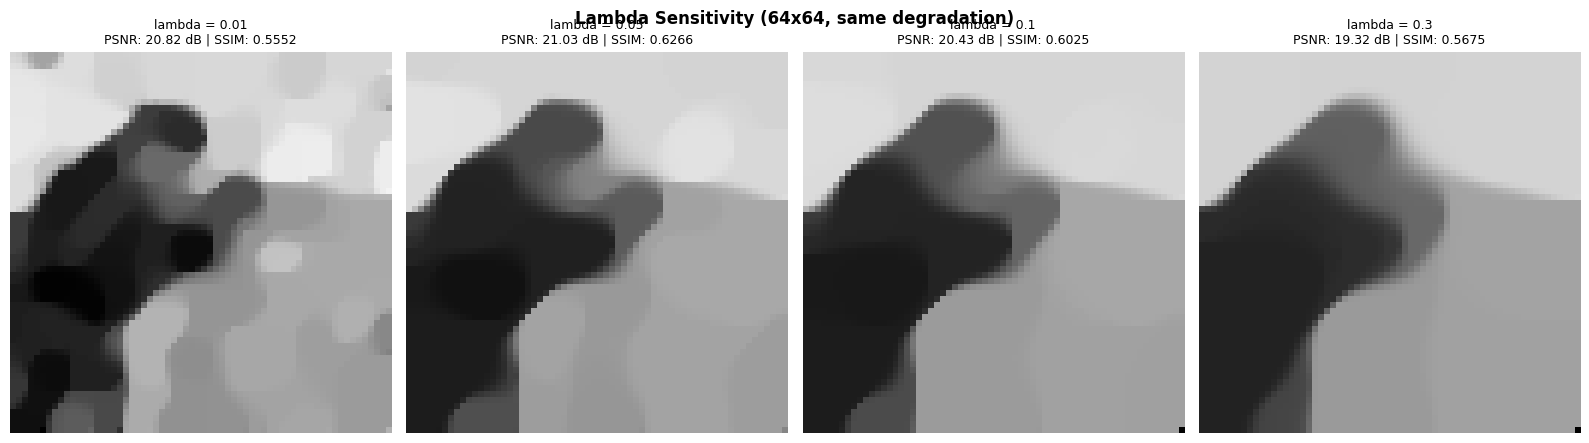

In [13]:
display_lams = [0.01, 0.05, 0.1, 0.3]
sweep_imgs   = []

for lam in display_lams:
    u_var = cp.Variable(N_small * N_small)
    u_2d  = cp.reshape(u_var, (N_small, N_small), order='C')
    prob  = cp.Problem(
        cp.Minimize(0.5 * cp.sum_squares(K_small @ u_var - f_obs_s.ravel()) + lam * cp.tv(u_2d)),
        [u_var >= 0, u_var <= 1]
    )
    prob.solve(solver=cp.SCS, verbose=False, eps=1e-4, max_iters=5000)
    sweep_imgs.append(np.clip(u_var.value.reshape(N_small, N_small), 0.0, 1.0))

fig, axes = plt.subplots(1, len(display_lams), figsize=(4 * len(display_lams), 4.5))
for ax, img, lam in zip(axes, sweep_imgs, display_lams):
    p = psnr(u_true_s, img, data_range=1.0)
    s = ssim(u_true_s, img, data_range=1.0)
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"lambda = {lam}\nPSNR: {p:.2f} dB | SSIM: {s:.4f}", fontsize=9)
    ax.axis('off')

plt.suptitle('Lambda Sensitivity (64x64, same degradation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_lambda_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

In [14]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Image size     : {N}x{N}")
print(f"Blur kernel    : Gaussian sigma={BLUR_SIGMA}, size {KERNEL_SIZE}x{KERNEL_SIZE}")
print(f"Noise          : Salt-and-pepper p={NOISE_PROB}")
print(f"Lambda (main)  : {LAMBDA}")
print(f"Solver         : SCS (via CVXPY {cp.__version__})")
print(f"TV type        : Isotropic (cp.tv - rotation-invariant, no diagonal bias)")
print(f"K boundary     : Row-normalized (consistent forward model at boundaries)")
print()
print(f"{'Method':<25} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 45)
best_psnr = max(r['psnr'] for r in results)
for r in results:
    marker = "  <- best" if r['psnr'] == best_psnr else ""
    print(f"{r['name']:<25} {r['psnr']:>10.2f} {r['ssim']:>8.4f}{marker}")
print("=" * 60)
print(f"\nPareto-optimal lambda (64x64) : {lams[best_p_idx]}  ->  PSNR={psnrs[best_p_idx]:.2f} dB")
print(f"All figures saved to          : {os.path.abspath(OUTPUT_DIR)}/")

SUMMARY
Image size     : 128x128
Blur kernel    : Gaussian sigma=3.0, size 11x11
Noise          : Salt-and-pepper p=0.05
Lambda (main)  : 0.05
Solver         : SCS (via CVXPY 1.8.2)
TV type        : Isotropic (cp.tv - rotation-invariant, no diagonal bias)
K boundary     : Row-normalized (consistent forward model at boundaries)

Method                     PSNR (dB)     SSIM
---------------------------------------------
Degraded (f_obs)               16.60   0.2290
Gaussian filter                21.06   0.5278
Median filter                  22.04   0.6674
TV model (ours)                22.53   0.6590  <- best

Pareto-optimal lambda (64x64) : 0.02  ->  PSNR=21.28 dB
All figures saved to          : /Users/reynaldi/Documents/convex_441/ipynb/outputs/
